# Series y Dataframes: Pandas

### 📊 ¿Qué es una Serie en pandas?

Una Series es un array unidimensional con etiquetas (índices). Es como una columna de una hoja de cálculo o una tabla de base de datos.

#### 🧱 Características clave:
- Contiene datos (de cualquier tipo: enteros, cadenas, flotantes, etc.).
- Tiene un índice que etiqueta cada elemento.
- Es mutable (puedes cambiar sus valores).
- Puede manejar valores nulos (NaN).

In [2]:
import pandas as pd

# Crear una Serie a partir de una lista
s = pd.Series([10, 20, 30, 40])

print(s)


0    10
1    20
2    30
3    40
dtype: int64


### 🧠 ¿Para qué se usa?

- Análisis de datos unidimensionales
- Series temporales
- Estadísticas y operaciones vectorizadas
- Como base para construir un DataFrame (estructura bidimensional)

In [3]:
import pandas as pd

serie = pd.Series([10, 20, 30])
df    = serie.to_frame(name='valores')
print(df)


   valores
0       10
1       20
2       30


In [4]:
df = pd.DataFrame({'valores': serie})
print(df)


   valores
0       10
1       20
2       30


In [5]:
serie2 = pd.Series(['rojo', 'azul', 'verde'])

df = pd.DataFrame({'valores': serie,'colores':serie2})
print(df)

   valores colores
0       10    rojo
1       20    azul
2       30   verde


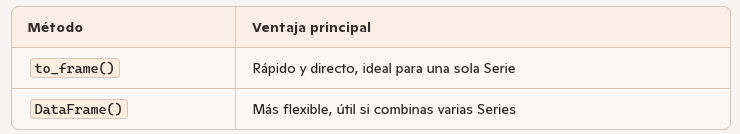

## Dataframe

Carga estos datos

In [6]:
df = pd.read_csv ('precios.csv',sep=';')

In [7]:
df.head(3)

,Unnamed: 0,fecha,producto,precio,unidades,ciudad,categoria,importe
0,0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20
1,1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98
2,2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05


In [8]:
#eliminamos la columnas Unnammed
df = df.drop('Unnamed: 0', axis=1)

In [30]:
# Usando del
del df['Unnamed: 0']

KeyError: 'Unnamed: 0'

In [9]:
df.head(3)

,fecha,producto,precio,unidades,ciudad,categoria,importe
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05


In [10]:
#añadimos la columna descuento
df['descuento']=None

In [11]:
df['ingreso_unitario'] = df['importe'] / df['unidades']

In [12]:
df.head(3)

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ingreso_unitario
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None,193.10
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None,99.66
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None,98.35


In [24]:
df.dtypes

fecha                object
producto             object
precio              float64
unidades              int64
ciudad               object
categoria            object
importe             float64
descuento            object
ingreso_unitario    float64
dtype: object

### Métodos de inspección: .head(), .tail(), .shape, .info(), .describe()

In [13]:
df.head()#inicio

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ingreso_unitario
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None,193.10
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None,99.66
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None,98.35
3,2024-01-01 03:00:00,C,181.02,6,Barcelona,Deporte,1086.12,None,181.02
4,2024-01-01 04:00:00,D,8.10,3,Valencia,Moda,24.30,None,8.10


In [41]:
df.head(2)#dos primeras filas

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None


In [42]:
df.tail() #final

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento
995,2024-02-11 11:00:00,D,72.69,7,Valencia,Moda,508.83,None
996,2024-02-11 12:00:00,D,174.67,8,Barcelona,Moda,1397.36,None
997,2024-02-11 13:00:00,D,166.01,2,Valencia,Moda,332.02,None
998,2024-02-11 14:00:00,A,26.83,3,Valencia,Electrónica,80.49,None
999,2024-02-11 15:00:00,B,136.78,4,Barcelona,Hogar,547.12,None


In [14]:
len(df)

1000

In [43]:
df.shape #filas y columnas

(1000, 8)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      1000 non-null   object 
 1   producto   1000 non-null   object 
 2   precio     1000 non-null   float64
 3   unidades   1000 non-null   int64  
 4   ciudad     1000 non-null   object 
 5   categoria  1000 non-null   object 
 6   importe    1000 non-null   float64
 7   descuento  0 non-null      object 
dtypes: float64(2), int64(1), object(5)
memory usage: 62.6+ KB


In [45]:
df.describe()

,precio,unidades,importe
count,1000.000000,1000.000000,1000.000000
mean,100.555440,2.985000,296.264970
std,56.832824,1.733141,257.424304
min,5.040000,0.000000,0.000000
25%,51.177500,2.000000,99.720000
50%,100.410000,3.000000,224.630000
75%,150.790000,4.000000,440.740000
max,199.950000,10.000000,1949.100000


#### Mini ejercicio (3’)

- Muestra las 2 ultimas filas.
- ¿Cuántas filas/columnas hay?
- ¿Qué tipo de dato es fecha?

### .isna(), .fillna() y .dropna()

#### 🔍 .isna(): Detectar valores nulos

¿Qué hace? Devuelve un objeto del mismo tamaño que el original, con True donde hay valores nulos (NaN) y False donde no.

In [15]:
df.isna()

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ingreso_unitario
0,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,True,False
996,False,False,False,False,False,False,False,True,False
997,False,False,False,False,False,False,False,True,False
998,False,False,False,False,False,False,False,True,False


In [33]:
#Aplicación común: Para contar valores nulos:
df.isna().sum()


fecha                  0
producto               0
precio                 0
unidades               0
ciudad                 0
categoria              0
importe                0
descuento           1000
ingreso_unitario      56
dtype: int64

#### 🧴 .fillna(): Rellenar valores nulos

¿Qué hace? Reemplaza los valores nulos (NaN) con un valor específico o con una estrategia (como interpolación o propagación).

In [16]:
df.fillna(0)  # Rellena con ceros
df.fillna(method='ffill')  # Propaga el último valor válido hacia adelante
df.fillna(method='bfill')  # Propaga el siguiente valor válido hacia atrás
#Aplicación común: Evitar errores en cálculos estadísticos o modelos que no aceptan valores nulos.

C:\Users\tteru\AppData\Local\Temp\ipykernel_16144\2660893678.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0)  # Rellena con ceros
C:\Users\tteru\AppData\Local\Temp\ipykernel_16144\2660893678.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill')  # Propaga el último valor válido hacia adelante
C:\Users\tteru\AppData\Local\Temp\ipykernel_16144\2660893678.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill')  # Propaga el siguiente valor válido hacia atrás


,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ingreso_unitario
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None,193.10
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None,99.66
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None,98.35
3,2024-01-01 03:00:00,C,181.02,6,Barcelona,Deporte,1086.12,None,181.02
4,2024-01-01 04:00:00,D,8.10,3,Valencia,Moda,24.30,None,8.10
...,...,...,...,...,...,...,...,...,...
995,2024-02-11 11:00:00,D,72.69,7,Valencia,Moda,508.83,None,72.69
996,2024-02-11 12:00:00,D,174.67,8,Barcelona,Moda,1397.36,None,174.67
997,2024-02-11 13:00:00,D,166.01,2,Valencia,Moda,332.02,None,166.01
998,2024-02-11 14:00:00,A,26.83,3,Valencia,Electrónica,80.49,None,26.83


#### 🧹 .dropna(): Eliminar valores nulos

Elimina filas o columnas que contienen valores nulos.

In [17]:
df.dropna()  # Elimina filas con al menos un NaN
df.dropna(axis=1)  # Elimina columnas con al menos un NaN
df.dropna(thresh=2)  # Conserva filas con al menos 2 valores no nulos


,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ingreso_unitario
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None,193.10
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None,99.66
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None,98.35
3,2024-01-01 03:00:00,C,181.02,6,Barcelona,Deporte,1086.12,None,181.02
4,2024-01-01 04:00:00,D,8.10,3,Valencia,Moda,24.30,None,8.10
...,...,...,...,...,...,...,...,...,...
995,2024-02-11 11:00:00,D,72.69,7,Valencia,Moda,508.83,None,72.69
996,2024-02-11 12:00:00,D,174.67,8,Barcelona,Moda,1397.36,None,174.67
997,2024-02-11 13:00:00,D,166.01,2,Valencia,Moda,332.02,None,166.01
998,2024-02-11 14:00:00,A,26.83,3,Valencia,Electrónica,80.49,None,26.83


In [18]:
df.dropna(axis=1) 

,fecha,producto,precio,unidades,ciudad,categoria,importe
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05
3,2024-01-01 03:00:00,C,181.02,6,Barcelona,Deporte,1086.12
4,2024-01-01 04:00:00,D,8.10,3,Valencia,Moda,24.30
...,...,...,...,...,...,...,...
995,2024-02-11 11:00:00,D,72.69,7,Valencia,Moda,508.83
996,2024-02-11 12:00:00,D,174.67,8,Barcelona,Moda,1397.36
997,2024-02-11 13:00:00,D,166.01,2,Valencia,Moda,332.02
998,2024-02-11 14:00:00,A,26.83,3,Valencia,Electrónica,80.49


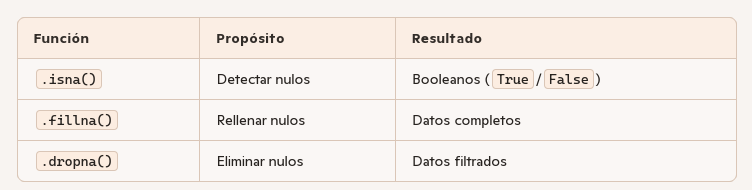

### Indexación y filtrado

Tipos principales de indexación:
- 1. Por etiqueta con .loc[]
Accede a filas y columnas usando nombres (etiquetas).

Sintaxis: df.loc[fila, columna]

In [19]:
df.loc[7, 'ciudad']


'Sevilla'

In [59]:
df.loc[:, 'ciudad']  # Todas las filas, solo ciudad

0         Madrid
1      Barcelona
2       Valencia
3      Barcelona
4       Valencia
         ...    
995     Valencia
996    Barcelona
997     Valencia
998     Valencia
999    Barcelona
Name: ciudad, Length: 1000, dtype: object

Cambiamos el precio a la fila 0

In [26]:
df.loc[0, 'precio'] = 99

In [ ]:
Cambiamos el valor de una columna por posición

In [112]:
#fila 0 columna 3
df.iloc[0, 3] = 60

df['precio'][0] = 120.0

- 2. Por posición con .iloc[]
Accede por índices numéricos (como en listas).

Sintaxis: df.iloc[fila, columna]

In [60]:
df.iloc[0, 1]  # Primera fila, segunda columna

'D'

In [61]:
df.iloc[:, 0]  # Todas las filas, primera columna

0      2024-01-01 00:00:00
1      2024-01-01 01:00:00
2      2024-01-01 02:00:00
3      2024-01-01 03:00:00
4      2024-01-01 04:00:00
              ...         
995    2024-02-11 11:00:00
996    2024-02-11 12:00:00
997    2024-02-11 13:00:00
998    2024-02-11 14:00:00
999    2024-02-11 15:00:00
Name: fecha, Length: 1000, dtype: object

In [62]:
df.iloc[0]

fecha        2024-01-01 00:00:00
producto                       D
precio                     193.1
unidades                       2
ciudad                    Madrid
categoria                   Moda
importe                    386.2
descuento                   None
Name: 0, dtype: object

In [63]:
df.iloc[-1]

fecha        2024-02-11 15:00:00
producto                       B
precio                    136.78
unidades                       4
ciudad                 Barcelona
categoria                  Hogar
importe                   547.12
descuento                   None
Name: 999, dtype: object

In [64]:
row = df.iloc[-1]

In [65]:
print(row['importe'])

547.12


- 3. Acceso directo por nombre de columna
Puedes acceder a una columna como si fuera un atributo o clave:

In [67]:
df['precio']

0      193.10
1       99.66
2       98.35
3      181.02
4        8.10
        ...  
995     72.69
996    174.67
997    166.01
998     26.83
999    136.78
Name: precio, Length: 1000, dtype: float64

In [68]:
df.precio  # Solo si el nombre no tiene espacios ni caracteres especiales

0      193.10
1       99.66
2       98.35
3      181.02
4        8.10
        ...  
995     72.69
996    174.67
997    166.01
998     26.83
999    136.78
Name: precio, Length: 1000, dtype: float64

###  Filtrado de datos

In [70]:
df[df['precio'] > 26.8]


,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None
3,2024-01-01 03:00:00,C,181.02,6,Barcelona,Deporte,1086.12,None
5,2024-01-01 05:00:00,D,174.43,5,Barcelona,Moda,872.15,None
...,...,...,...,...,...,...,...,...
995,2024-02-11 11:00:00,D,72.69,7,Valencia,Moda,508.83,None
996,2024-02-11 12:00:00,D,174.67,8,Barcelona,Moda,1397.36,None
997,2024-02-11 13:00:00,D,166.01,2,Valencia,Moda,332.02,None
998,2024-02-11 14:00:00,A,26.83,3,Valencia,Electrónica,80.49,None


In [71]:
prc_df =df[df['precio'] > 26.8]

In [72]:
prc_df.head(2)

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None


In [73]:
ciu_df = df[(df['precio'] > 30) & (df['ciudad'] == 'Madrid')]


In [74]:
ciu_df.head(3)

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None
16,2024-01-01 16:00:00,C,187.01,4,Madrid,Deporte,748.04,None
29,2024-01-02 05:00:00,C,96.16,1,Madrid,Deporte,96.16,None


#### .isin()

In [75]:
df_2 = df[df['ciudad'].isin(['Madrid', 'Sevilla'])]


In [76]:
df_2

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None
7,2024-01-01 07:00:00,D,78.94,2,Sevilla,Moda,157.88,None
15,2024-01-01 15:00:00,C,118.95,0,Sevilla,Deporte,0.00,None
16,2024-01-01 16:00:00,C,187.01,4,Madrid,Deporte,748.04,None
19,2024-01-01 19:00:00,C,27.81,6,Madrid,Deporte,166.86,None
...,...,...,...,...,...,...,...,...
982,2024-02-10 22:00:00,C,165.60,3,Sevilla,Deporte,496.80,None
985,2024-02-11 01:00:00,A,114.98,5,Madrid,Electrónica,574.90,None
986,2024-02-11 02:00:00,B,77.42,4,Sevilla,Hogar,309.68,None
992,2024-02-11 08:00:00,B,117.87,0,Madrid,Hogar,0.00,None


### contains()

In [80]:
df_2 = df[df['categoria'].str.contains('Moda','Hogar')]

## Eliminar filas

In [114]:
#elimina todas las filas con cualquier columna a null
df = df.dropna()

In [115]:
df.head(2)

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ventas_normalizadas,año,mes,día,ingreso_unitario


In [ ]:
#elimina filas donde la columna precio sea null o la columna unidades
df = df.dropna(subset=['precio', 'unidades'])


In [ ]:
#Conserva solo las filas que tienen al menos 5 valores no nulos.
df = df.dropna(thresh=5)

In [ ]:
#eliminar filas donde el precio sea 0:
df = df[df['precio'] != 0]

## 📚 Tema: Funciones de Agrupación en pandas

Las funciones de agrupación permiten agrupar datos según una o más columnas y aplicar operaciones estadísticas o de resumen. Son esenciales para el análisis exploratorio y la transformación de datos.

#### 🔗 1. ¿Qué es groupby()?
La función groupby() de pandas divide el DataFrame en grupos según los valores de una o más columnas.

In [82]:
df.groupby('producto')

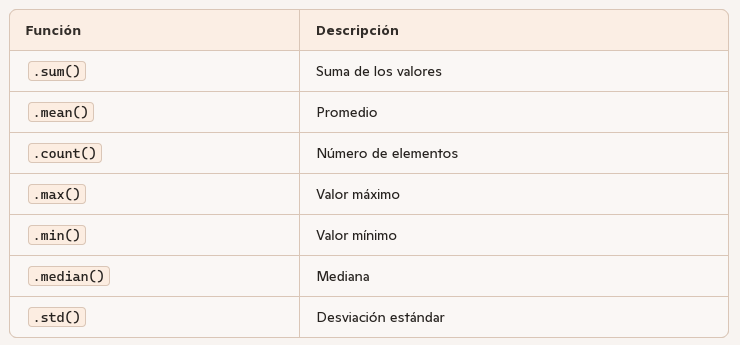

In [85]:
df.groupby('ciudad')['importe'].sum()

ciudad
Barcelona    68458.47
Madrid       74460.66
Sevilla      74337.89
Valencia     79007.95
Name: importe, dtype: float64

In [86]:
df.groupby('producto')['producto'].count()

producto
A    265
B    241
C    240
D    254
Name: producto, dtype: int64

In [ ]:
#media de precio por categoria

In [109]:
df.groupby('categoria')['precio'].mean()

categoria
Deporte         93.844875
Electrónica    104.774906
Hogar          102.157095
Moda           100.974252
Name: precio, dtype: float64

In [87]:
df.groupby(['ciudad', 'producto'])['importe'].mean()


ciudad     producto
Barcelona  A           243.606190
           B           270.428906
           C           203.513077
           D           382.635254
Madrid     A           279.768033
           B           329.005484
           C           340.543559
           D           264.131250
Sevilla    A           316.541875
           B           352.150536
           C           234.735593
           D           315.528923
Valencia   A           323.941558
           B           282.093220
           C           301.949825
           D           306.209242
Name: importe, dtype: float64

Usa .agg() para aplicar varias funciones a la vez:

In [88]:
df.groupby('ciudad')['importe'].agg(['sum', 'mean', 'max'])

,sum,mean,max
ciudad,,,
Barcelona,68458.47,272.742908,1397.36
Madrid,74460.66,302.685610,1949.10
Sevilla,74337.89,304.663484,1261.04
Valencia,79007.95,305.050000,1395.63


También puedes usar funciones personalizadas:

In [89]:
df.groupby('ciudad')['importe'].agg(lambda x: x.max() - x.min())


ciudad
Barcelona    1397.36
Madrid       1949.10
Sevilla      1261.04
Valencia     1395.63
Name: importe, dtype: float64

Después de agrupar, el índice suele cambiar. Puedes restaurarlo con:

In [90]:
df.groupby('ciudad')['importe'].sum().reset_index()

,ciudad,importe
0,Barcelona,68458.47
1,Madrid,74460.66
2,Sevilla,74337.89
3,Valencia,79007.95


In [107]:
# el producto con mas unidades

In [108]:
df.groupby('producto')['unidades'].sum().sort_values(ascending=False).head(1)


producto
D    799
Name: unidades, dtype: int64

##### Filtrar grupos con filter()

In [91]:
df.groupby('ciudad').filter(lambda x: x['importe'].sum() > 1000)

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None
3,2024-01-01 03:00:00,C,181.02,6,Barcelona,Deporte,1086.12,None
4,2024-01-01 04:00:00,D,8.10,3,Valencia,Moda,24.30,None
...,...,...,...,...,...,...,...,...
995,2024-02-11 11:00:00,D,72.69,7,Valencia,Moda,508.83,None
996,2024-02-11 12:00:00,D,174.67,8,Barcelona,Moda,1397.36,None
997,2024-02-11 13:00:00,D,166.01,2,Valencia,Moda,332.02,None
998,2024-02-11 14:00:00,A,26.83,3,Valencia,Electrónica,80.49,None


#### Transformar grupos con transform()

In [93]:
df['ventas_normalizadas'] = df.groupby('ciudad')['importe'].transform(lambda x: x / x.sum())
df.head(3)

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ventas_normalizadas
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None,0.005187
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None,0.004367
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None,0.003734


In [ ]:
#precios superiores a la media

In [ ]:
df[df['precio'] > df['precio'].mean()]

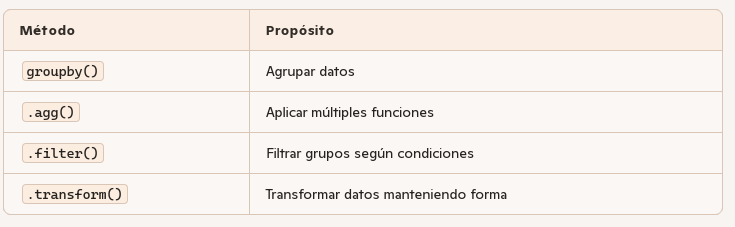

## Conversion de tipos

In [116]:
df.dtypes

fecha                  datetime64[ns]
producto                       object
precio                        float64
unidades                        int64
ciudad                         object
categoria                      object
importe                       float64
descuento                      object
ventas_normalizadas           float64
año                             int32
mes                             int32
día                             int32
ingreso_unitario              float64
dtype: object

In [ ]:
df['precio'] = pd.to_numeric(df['precio'], errors='coerce')

In [ ]:
df['precio'] = df['precio'].astype(float)

In [ ]:
columnas = ['precio', 'unidades', 'importe']
df[columnas] = df[columnas].apply(pd.to_numeric, errors='coerce')


## Funciones

La función .apply() permite aplicar una función personalizada o predefinida a cada elemento, fila o columna de un DataFrame o Series. Es una herramienta poderosa para transformar datos de forma flexible.

- axis=0: aplica la función a cada columna.
- axis=1: aplica la función a cada fila.

In [ ]:
df.apply(funcion, axis=0)  # Por columnas
df.apply(funcion, axis=1)  # Por filas

In [117]:
df['precio_con_iva'] = df['precio'].apply(lambda x: x * 1.21)

In [ ]:
#Aplicar una función a cada fila
df['total'] = df.apply(lambda fila: fila['precio'] * fila['unidades'], axis=1)

In [ ]:
#con funciones predefinidas
df['producto'] = df['producto'].apply(str.upper)

## 🕒 Manual de uso: pd.to_datetime()

La función pd.to_datetime() convierte datos en formato de texto u otros tipos en fechas y horas reconocibles por pandas. Es fundamental para trabajar con series temporales, agrupar por fechas o realizar análisis cronológicos.

### 📌 ¿Para qué sirve?

- Transformar cadenas como "2025-11-10" en objetos de tipo datetime.
- Facilitar operaciones como extraer el año, mes, día, etc.
- Permitir ordenamientos, filtrados y agrupaciones por fecha.

In [94]:
import pandas as pd

fechas = ['2025-01-01', '2025-02-15', '2025-03-30']
serie_fechas = pd.to_datetime(fechas)

print(serie_fechas)


DatetimeIndex(['2025-01-01', '2025-02-15', '2025-03-30'], dtype='datetime64[ns]', freq=None)


Convertir una columna de texto en fechas

In [95]:
df['fecha'] = pd.to_datetime(df['fecha'])


In [96]:
df.dtypes

fecha                  datetime64[ns]
producto                       object
precio                        float64
unidades                        int64
ciudad                         object
categoria                      object
importe                       float64
descuento                      object
ventas_normalizadas           float64
dtype: object

In [97]:
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['día'] = df['fecha'].dt.day


In [98]:
df.head(3)

,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ventas_normalizadas,año,mes,día
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None,0.005187,2024,1,1
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None,0.004367,2024,1,1
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None,0.003734,2024,1,1


Filtrar por rango de fechas

In [102]:
df[(df['fecha'] >= '2024-01-01') & (df['fecha'] <= '2024-03-31')].head(3)


,fecha,producto,precio,unidades,ciudad,categoria,importe,descuento,ventas_normalizadas,año,mes,día
0,2024-01-01 00:00:00,D,193.10,2,Madrid,Moda,386.20,None,0.005187,2024,1,1
1,2024-01-01 01:00:00,A,99.66,3,Barcelona,Electrónica,298.98,None,0.004367,2024,1,1
2,2024-01-01 02:00:00,B,98.35,3,Valencia,Hogar,295.05,None,0.003734,2024,1,1


Agrupar por mes o año

In [103]:
df.groupby(df['fecha'].dt.month)['importe'].sum()


fecha
1    224807.41
2     71457.56
Name: importe, dtype: float64

Con formato

In [104]:
#El parámetro dayfirst=True en la función pd.to_datetime() indica que el día aparece antes que el mes en las fechas que estás convirtiendo.
pd.to_datetime(df['fecha'], format='%d/%m/%Y', dayfirst=True)


0     2024-01-01 00:00:00
1     2024-01-01 01:00:00
2     2024-01-01 02:00:00
3     2024-01-01 03:00:00
4     2024-01-01 04:00:00
              ...        
995   2024-02-11 11:00:00
996   2024-02-11 12:00:00
997   2024-02-11 13:00:00
998   2024-02-11 14:00:00
999   2024-02-11 15:00:00
Name: fecha, Length: 1000, dtype: datetime64[ns]

In [106]:
import pandas as pd

fechas = ['10/11/2025', '05/12/2025']  # Formato DD/MM/YYYY

# Sin dayfirst
print(pd.to_datetime(fechas))
# Interpreta como MM/DD/YYYY → 10 de octubre, 5 de mayo

# Con dayfirst
print(pd.to_datetime(fechas, dayfirst=True))
# Interpreta correctamente → 10 de noviembre, 5 de diciembre


DatetimeIndex(['2025-10-11', '2025-05-12'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2025-11-10', '2025-12-05'], dtype='datetime64[ns]', freq=None)


## Hand on 

- Crear una nueva columna llamada mes que contenga el mes de cada venta.
- Filtrar las ventas realizadas en la ciudad de "Madrid" durante el mes de marzo.
- Calcular el importe total vendido por cada categoría.
- Eliminar las filas donde el campo precio sea nulo.
- Crear una nueva columna llamada ingreso_unitario que sea importe / unidades.
- Mostrar el producto con mayor ingreso unitario promedio.
- Mostrar el producto con mayor ingreso unitario promedio.